In [2]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib as mpl
import numpy as np

### Helping Functions

In [3]:
def load_img(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"Missing file: {path}")
    return np.asarray(Image.open(path))


def show_img(ax, img, title=None, panel_label=None):
    ax.imshow(img)
    ax.axis("off")

    if title is not None:
        ax.set_title(title, fontsize=11, pad=4)

    if panel_label is not None:
        ax.text(
            0.01, 0.99,
            panel_label,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=13,
            fontweight="bold",
            color="black",
            bbox=dict(facecolor="white", alpha=0.75, edgecolor="none", pad=2)
        )
        
        
        
def show_panel(fig, img, rect):
    ax = fig.add_axes(rect)
    ax.imshow(img, aspect="auto")
    ax.axis("off")
    return ax
        


def crop_to_box_aspect_bottom_left(img, rect):
    """
    Crop image to match target rect aspect ratio.
    Always keeps the bottom-left corner fixed.
    
    This is useful when the axis origin is at the lower-left corner
    and should stay aligned with the displayed panel.
    """
    h, w = img.shape[:2]

    target_ratio = rect[2] / rect[3]   # box width / box height
    img_ratio = w / h

    if img_ratio > target_ratio:
        # image too wide -> crop from the RIGHT
        new_w = int(round(h * target_ratio))
        return img[:, :new_w]

    else:
        # image too tall -> crop from the TOP
        new_h = int(round(w / target_ratio))
        return img[h - new_h:, :]
    
    
    
def crop_to_box_aspect_left_center_y(img, rect):
    """
    Crop image to match target rect aspect ratio.
    Keeps left edge fixed for x-alignment.
    If height needs cropping, crop symmetrically around vertical center.
    """
    h, w = img.shape[:2]

    target_ratio = rect[2] / rect[3]   # box width / box height
    img_ratio = w / h

    if img_ratio > target_ratio:
        # image too wide -> crop from RIGHT, keep left edge
        new_w = int(round(h * target_ratio))
        return img[:, :new_w]

    else:
        # image too tall -> crop TOP/BOTTOM symmetrically, keep center
        new_h = int(round(w / target_ratio))
        y0 = (h - new_h) // 2
        return img[y0:y0 + new_h, :]

    

def crop_fixed_margins(img, left=0, right=0, top=0, bottom=0):
    """
    Crops the same fixed pixel margins from all sides.
    """
    h, w = img.shape[:2]
    return img[top:h-bottom, left:w-right]



def draw_axis_icon(fig, ax, plane, color="black", fontsize=16, lw=2.0, icon_size=0.060):
    """
    Draw equal-size axis icon at lower-left corner of a panel.
    icon_size is in figure coordinates, so all icons have the same visual size.
    """
    if plane == "XY":
        labels = ("x", "y")
    elif plane == "XZ":
        labels = ("x", "z")
    elif plane == "YZ":
        labels = ("z", "y")   # paper-like YZ
    else:
        labels = ("x", "z")

    # Get panel position in figure coordinates
    bbox = ax.get_position()

    # Create fixed-size square icon axes at the lower-left of the panel
    icon_ax = fig.add_axes(
        [bbox.x0, bbox.y0, icon_size, icon_size],
        zorder=20
    )

    icon_ax.set_xlim(0, 1)
    icon_ax.set_ylim(0, 1)
    icon_ax.set_aspect("equal")
    icon_ax.axis("off")
    icon_ax.patch.set_alpha(0)

    x0, y0 = 0.0, 0.0
    L = 0.72

    # axis lines
    icon_ax.plot([x0, L], [y0, y0], color=color, lw=lw, solid_capstyle="butt", clip_on=False)
    icon_ax.plot([x0, x0], [y0, L], color=color, lw=lw, solid_capstyle="butt", clip_on=False)

    # arrowheads
    icon_ax.plot(L, y0, marker=">", markersize=7, color=color, clip_on=False)
    icon_ax.plot(x0, L, marker="^", markersize=7, color=color, clip_on=False)

    # labels
    icon_ax.text(
        L + 0.18, y0 - 0.14,
        labels[0],
        fontsize=fontsize,
        ha="left",
        va="center",
        color=color,
        clip_on=False
    )

    icon_ax.text(
        x0 - 0.16, L + 0.05,
        labels[1],
        fontsize=fontsize,
        ha="right",
        va="bottom",
        color=color,
        clip_on=False
    )

# FBP

In [7]:
base_dir = Path("../../figures/baseline/slices")

case_name = "FBP"

paths = {
    "XY": base_dir / "FBP_XY_Slice.png",
    "XZ": base_dir / "FBP_XZ_Slice.png",
    "YZ": base_dir / "FBP_YZ_Slice.png",
    "Fourier": base_dir / "FBP_Fourier_XZ_Slice.png",
}

export_dir = Path("../../figures/final_report/baseline")
export_dir.mkdir(parents=True, exist_ok=True)


#Fourier
fourier_cmap = "gray"
fourier_vmin = 1.7231421
fourier_vmax = 32.951424

#fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)

# DDW

In [18]:
base_dir = Path("../../figures/baseline/slices")

case_name = "DDW"

paths = {
    "XY": base_dir / "DDW_XY_Slice.png",
    "XZ": base_dir / "DDW_XZ_Slice.png",
    "YZ": base_dir / "DDW_YZ_Slice.png",
    "Fourier": base_dir / "DDW_Fourier_XZ_Slice.png",
}

export_dir = Path("../../figures/final_report/baseline")
export_dir.mkdir(parents=True, exist_ok=True)


#Fourier
fourier_cmap = "gray"
fourier_vmin = 1.7231421
fourier_vmax = 32.951424

#fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)

# OWN MODEL

In [4]:
base_dir = Path("../../figures/baseline/slices")

case_name = "OWN"

paths = {
    "XY": base_dir / "OWN_XY_Slice.png",
    "XZ": base_dir / "OWN_XZ_Slice.png",
    "YZ": base_dir / "OWN_YZ_Slice.png",
    "Fourier": base_dir / "OWN_Fourier_XZ_Slice.png",
}

export_dir = Path("../../figures/final_report/baseline")
export_dir.mkdir(parents=True, exist_ok=True)


#Fourier
fourier_cmap = "gray"
fourier_vmin = 1.7231421
fourier_vmax = 32.951424

#fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)

### Loading images after choosing the case

In [8]:
imgs = {key: load_img(path) for key, path in paths.items()}

# same crop for all images
crop_left   = 6
crop_right  = 5
crop_top    = 5
crop_bottom = 40 #6

imgs = {
    key: crop_fixed_margins(
        img,
        left=crop_left,
        right=crop_right,
        top=crop_top,
        bottom=crop_bottom
    )
    for key, img in imgs.items()
}

### PLOT

YZ [0.06, 0.52, 0.19499999999999998, 0.38]
XY [0.29, 0.52, 0.6699999999999999, 0.38]
XZ [0.29, 0.3, 0.6699999999999999, 0.16]
Fourier [0.29, 0.11, 0.6699999999999999, 0.15]


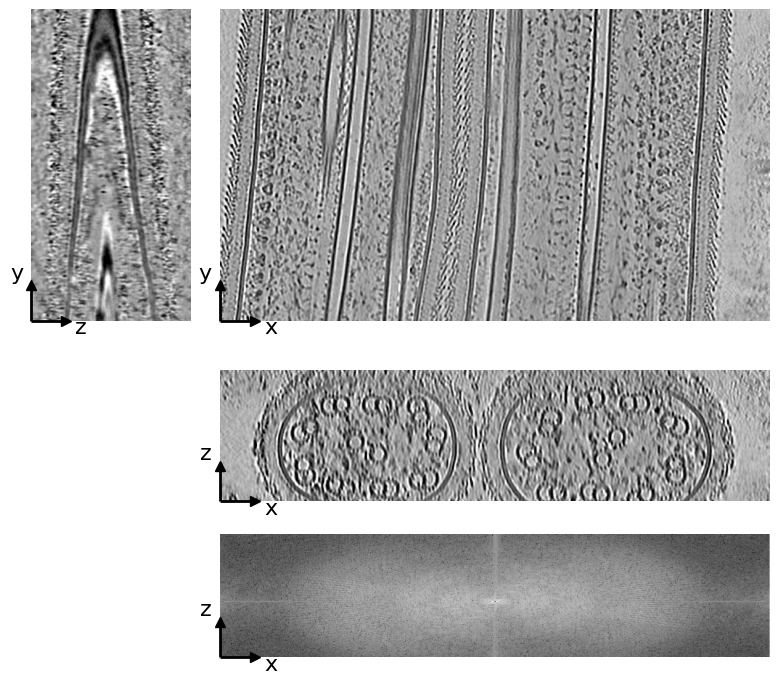

In [6]:
## plt.close("all")

fig = plt.figure(figsize=(8.2, 8.2))

# ------------------------------------------------------------
# Paper-like fixed boxes
# ------------------------------------------------------------

# Global layout
left_margin = 0.06
right_margin = 0.04

main_left = 0.29
main_w = 1.0 - main_left - right_margin

left_w = main_left - left_margin - 0.035

# Top block: XY and YZ
top_y = 0.52
top_h = 0.38

# Lower block: XZ + Fourier, together only about lower half
xz_y = 0.30
xz_h = 0.16

ft_y = 0.11
ft_h = 0.15

rect_yz = [left_margin, top_y, left_w, top_h]
rect_xy = [main_left,   top_y, main_w, top_h]

rect_xz = [main_left, xz_y, main_w, xz_h]
rect_ft = [main_left, ft_y, main_w, ft_h]

layout_rects = {
    "YZ": rect_yz,
    "XY": rect_xy,
    "XZ": rect_xz,
    "Fourier": rect_ft,
}

for k, v in layout_rects.items():
    print(k, v)
# ------------------------------------------------------------
# Draw fixed-layout panels
# ------------------------------------------------------------

img_yz = crop_to_box_aspect_bottom_left(imgs["YZ"], rect_yz)
img_xy = crop_to_box_aspect_bottom_left(imgs["XY"], rect_xy)

# for XZ-like panels: keep x-left alignment, but center in z-direction
img_xz = crop_to_box_aspect_left_center_y(imgs["XZ"], rect_xz)
img_ft = crop_to_box_aspect_left_center_y(imgs["Fourier"], rect_ft)

ax_yz = show_panel(fig, img_yz, rect_yz)
ax_xy = show_panel(fig, img_xy, rect_xy)
ax_xz = show_panel(fig, img_xz, rect_xz)
ax_ft = show_panel(fig, img_ft, rect_ft)

"""
# ------------------------------------------------------------
# Colorbar mappables
# ------------------------------------------------------------

real_sm = cm.ScalarMappable(norm=real_norm, cmap=overlay_cmap)
real_sm.set_array([])

fourier_norm = colors.Normalize(vmin=fourier_vmin, vmax=fourier_vmax)
fourier_sm = cm.ScalarMappable(norm=fourier_norm, cmap=fourier_cmap)
fourier_sm.set_array([])

# ------------------------------------------------------------
# Put both colorbars into the free left column
# same width as YZ panel -> cleaner
# ------------------------------------------------------------

cb_left = rect_yz[0]
cb_width = rect_yz[2]    
cb_height = 0.032

# vertical placement inside the empty lower-left region
cax_real = fig.add_axes([cb_left, 0.427, cb_width, cb_height])
cax_fourier = fig.add_axes([cb_left, 0.227, cb_width, cb_height])

cbar_real = fig.colorbar(real_sm, cax=cax_real, orientation="horizontal")
cbar_real.set_ticks([0.0, 0.1, 0.2])
cbar_real.ax.tick_params(labelsize=14, length=5, width=1)

cbar_fourier = fig.colorbar(fourier_sm, cax=cax_fourier, orientation="horizontal")
cbar_fourier.set_ticks([0, 1, 2, 3])
cbar_fourier.ax.tick_params(labelsize=14, length=5, width=1)

"""

# ------------------------------------------------------------
# Draw axis icons AFTER placement -> same size everywhere
# ------------------------------------------------------------

draw_axis_icon(fig, ax_yz, "YZ", color="black", fontsize=16, lw=2.0)
draw_axis_icon(fig, ax_xy, "XY", color="black", fontsize=16, lw=2.0)
draw_axis_icon(fig, ax_xz, "XZ", color="black", fontsize=16, lw=2.0)
draw_axis_icon(fig, ax_ft, "XZ", color="black", fontsize=16, lw=2.0)

plt.show()

### Export

In [7]:
save_png = export_dir / f"{case_name}.png"
save_pdf = export_dir / f"{case_name}.pdf"

fig.savefig(
    save_png,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

fig.savefig(
    save_pdf,
    bbox_inches="tight",
    pad_inches=0.03,
    facecolor="white"
)

print("Saved:", save_png)
print("Saved:", save_pdf)

Saved: ..\..\figures\final_report\baseline\OWN.png
Saved: ..\..\figures\final_report\baseline\OWN.pdf
